# 07 · เพิ่มเติม: เกรดเฉลี่ยและสภาพการเงิน

ตัวแปรควบคุมสองตัวนี้ไม่ได้อยู่ในคำถามวิจัยโดยตรง แต่ผลการถดถอยใน `06_q6_q7_regression.ipynb` ชี้ว่าการเงินเป็นตัวแปรที่น้ำหนักมากที่สุด จึงดูแยกอีกครั้ง

In [1]:
import os
import pathlib
import sys

# notebook.nvim starts the kernel in nvim's cwd; step into codingpy/ so common.py
# and data/ are found when the notebook is opened from the repo root
if pathlib.Path("codingpy/common.py").is_file():
    os.chdir("codingpy")
    sys.path.insert(0, os.getcwd())

%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from common import (
    ALPHA,
    DIMENSION_TH,
    DIMENSIONS,
    FIG_DIR,
    THAI_FONT,
    TITLE_SIZE,
    cohens_d,
    eta_squared,
    load_data,
    passed_attention,
)

df = passed_attention(load_data())  # the sample every research question uses
print(f"{len(df)} respondents passed the attention check")

107 respondents passed the attention check


## 7.1 ภาพรวม

- **เกรดเฉลี่ย** สหสัมพันธ์เพียร์สันกับคะแนนสามมิติ
- **ความเพียงพอทางการเงิน** (ให้คะแนนตนเอง 1 ถึง 10) เทียบคะแนนระหว่างทุกระดับด้วย Kruskal-Wallis


--- GPA vs DASS-21 (Pearson Correlation) ---
GPA x Depression: r = 0.044, p = 0.6551, n = 104
GPA x Anxiety: r = -0.004, p = 0.9677, n = 104
GPA x Stress: r = 0.063, p = 0.5278, n = 104

--- Financial Sufficiency vs DASS-21 (Kruskal-Wallis) ---
Financial x Depression: Kruskal-Wallis H = 21.269, p = 0.0115
Financial x Anxiety: Kruskal-Wallis H = 7.196, p = 0.6167
Financial x Stress: Kruskal-Wallis H = 12.929, p = 0.1658


Saved: ../figures/q6-gpa-finance.png


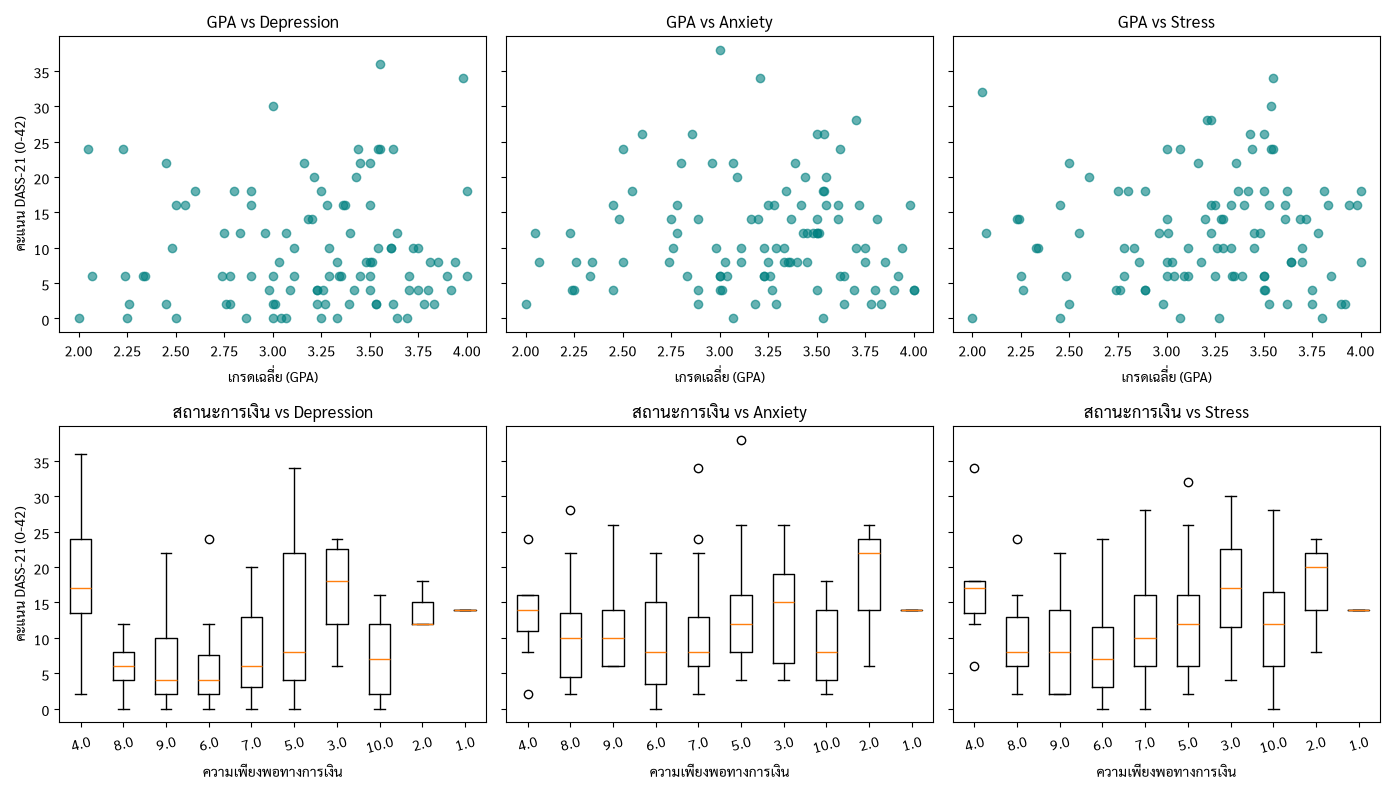

In [3]:
GPA_FINANCE_FIG_PATH = FIG_DIR / "q6-gpa-finance.png"


def gpa_finance_tests(df: pd.DataFrame) -> None:
    print("\n--- GPA vs DASS-21 (Pearson Correlation) ---")
    for col, name in DIMENSIONS.items():
        d = df[["GPA", col]].dropna()
        r, p = stats.pearsonr(d["GPA"], d[col])
        print(f"GPA x {name}: r = {r:.3f}, p = {p:.4f}, n = {len(d)}")

    print("\n--- Financial Sufficiency vs DASS-21 (Kruskal-Wallis) ---")
    for col, name in DIMENSIONS.items():
        groups = [group[col].dropna() for _, group in df.groupby("financial_sufficiency")]
        stat, p = stats.kruskal(*groups)
        print(f"Financial x {name}: Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")


def gpa_finance_plot(df: pd.DataFrame) -> None:
    plt.rcParams["font.family"] = THAI_FONT
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)

    # แถวที่ 1: GPA vs DASS-21 (Scatter plot)
    for ax, (col, name) in zip(axes[0], DIMENSIONS.items()):
        d = df[["GPA", col]].dropna()
        ax.scatter(d["GPA"], d[col], alpha=0.6, color="teal")
        ax.set_title(f"GPA vs {name}")
        ax.set_xlabel("เกรดเฉลี่ย (GPA)")

    axes[0, 0].set_ylabel("คะแนน DASS-21 (0-42)")

    # แถวที่ 2: Financial Sufficiency vs DASS-21 (Boxplot)
    fin_order = df["financial_sufficiency"].dropna().unique()
    for ax, (col, name) in zip(axes[1], DIMENSIONS.items()):
        data_to_plot = [df[df["financial_sufficiency"] == f][col].dropna() for f in fin_order]
        ax.boxplot(data_to_plot, tick_labels=fin_order)
        ax.set_title(f"สถานะการเงิน vs {name}")
        ax.set_xlabel("ความเพียงพอทางการเงิน")
        ax.tick_params(axis="x", rotation=15)

    axes[1, 0].set_ylabel("คะแนน DASS-21 (0-42)")

    fig.tight_layout()
    fig.savefig(GPA_FINANCE_FIG_PATH, dpi=200, facecolor="white")
    print(f"Saved: {GPA_FINANCE_FIG_PATH}")
    plt.show()


gpa_finance_tests(df)
gpa_finance_plot(df)

## 7.2 สภาพการเงิน 3 กลุ่ม (ANOVA)

การเทียบ 10 ระดับมีบางระดับที่ผู้ตอบน้อยมาก จึงจัดเป็น 3 กลุ่มแล้วเทียบค่าเฉลี่ย

| กลุ่ม | คะแนน | ความหมาย |
|---|---|---|
| low | 1 ถึง 4 | เงินไม่พอใช้ |
| mid | 5 ถึง 7 | พอใช้ |
| high | 8 ถึง 10 | สบาย |

แต่ละมิติรายงาน one-way ANOVA (มี Kruskal-Wallis ไว้ตรวจซ้ำด้วยอันดับ) ค่า η² บอกขนาดของความต่าง
Cohen's d ของกลุ่ม low เทียบ high และ r กับคะแนนดิบ 1 ถึง 10 เพื่อไม่ให้เสียข้อมูลจากการจัดกลุ่ม
ค่า r ของชั่วโมงใช้โซเชียลมีเดียพิมพ์ไว้ข้างกันเป็นไม้บรรทัดว่า "การเงินเกี่ยวกับคะแนนมากกว่าเวลาหน้าจอหรือไม่"

In [4]:
FINANCE = "financial_sufficiency"
BENCHMARK = "social_media_hours"  # the correlate 03_q1_q3_correlation.ipynb measured, for scale

# 1-10 self-rating cut into three money groups
GROUP_EDGES = [0, 4, 7, 10]
GROUPS = ["low", "mid", "high"]

# money level is ordered, so it gets one hue light -> dark, not three hues
GROUP_COLOR = {"low": "#86b6ef", "mid": "#2a78d6", "high": "#104281"}

GROUP_TH = {
    "low": "เงินไม่พอใช้ (1-4)",
    "mid": "พอใช้ (5-7)",
    "high": "สบาย (8-10)",
}

QR7_TITLES = {
    "title": "สภาพการเงินเปลี่ยนคะแนน DASS-21 ทั้งสามมิติหรือไม่",
    "subtitle": "เทียบคะแนนเฉลี่ยของกลุ่มเงินไม่พอ พอใช้ และสบาย — ซึมเศร้าต่างกันมากที่สุด",
}

QR7_FIG_PATH = FIG_DIR / "qr7-finance-dass-dimension.png"


def money_group(df: pd.DataFrame) -> pd.Series:
    """The 1-10 rating cut into low / mid / high, as an ordered category."""
    return pd.cut(df[FINANCE], bins=GROUP_EDGES, labels=GROUPS, ordered=True)


def dimension_stats(df: pd.DataFrame) -> pd.DataFrame:
    """One row per dimension: group means, ANOVA, eta^2, and both correlations."""
    group = money_group(df)
    rows = []
    for col, dimension in DIMENSIONS.items():
        d = (
            df[[col, FINANCE, BENCHMARK]]
            .assign(group=group)
            .dropna(subset=[col, "group"])
        )
        parts = [
            d.loc[d["group"] == name, col].to_numpy(dtype=float) for name in GROUPS
        ]
        F, p = stats.f_oneway(*parts)
        kw = stats.kruskal(*parts)
        money = d[[col, FINANCE]].dropna()
        screen = d[[col, BENCHMARK]].dropna()
        rows.append(
            {
                "dimension": dimension,
                **{f"mean_{name}": part.mean() for name, part in zip(GROUPS, parts)},
                **{
                    f"se_{name}": part.std(ddof=1) / np.sqrt(len(part))
                    for name, part in zip(GROUPS, parts)
                },
                **{f"n_{name}": len(part) for name, part in zip(GROUPS, parts)},
                "F": F,
                "p": p,
                "kruskal_p": kw.pvalue,
                "eta2": eta_squared(parts),
                "d_low_high": cohens_d(parts[0], parts[2]),
                "r_money": stats.pearsonr(money[col], money[FINANCE]).statistic,
                "p_money": stats.pearsonr(money[col], money[FINANCE]).pvalue,
                "r_screen": stats.pearsonr(screen[col], screen[BENCHMARK]).statistic,
            }
        )
    return pd.DataFrame(rows)


def report_money(table: pd.DataFrame) -> None:
    for row in table.itertuples():
        verdict = "reject H0" if float(row.p) < ALPHA else "fail to reject H0"
        print(
            f"\n{row.dimension}  "
            f"low {row.mean_low:.1f} (n = {row.n_low})  "
            f"mid {row.mean_mid:.1f} (n = {row.n_mid})  "
            f"high {row.mean_high:.1f} (n = {row.n_high})"
        )
        print(
            f"  one-way ANOVA F(2, {row.n_low + row.n_mid + row.n_high - 3}) = {row.F:.2f}, "
            f"p = {row.p:.4f} -> {verdict}; Kruskal-Wallis p = {row.kruskal_p:.4f}"
        )
        print(
            f"  eta^2 = {row.eta2:.3f}, low vs high Cohen's d = {row.d_low_high:+.2f}; "
            f"r with the raw 1-10 rating = {row.r_money:+.3f} (p = {row.p_money:.4f}), "
            f"against r = {row.r_screen:+.3f} for social media hours"
        )
    biggest = table.loc[table["eta2"].idxmax()]
    print(
        f"\nlargest gap: {biggest.dimension} "
        f"(eta^2 = {biggest.eta2:.3f}, low - high = "
        f"{biggest.mean_low - biggest.mean_high:.1f} points)"
    )


money_table = dimension_stats(df)
report_money(money_table)


Depression  low 16.6 (n = 18)  mid 8.9 (n = 54)  high 6.6 (n = 35)
  one-way ANOVA F(2, 104) = 10.91, p = 0.0000 -> reject H0; Kruskal-Wallis p = 0.0002
  eta^2 = 0.173, low vs high Cohen's d = +1.59; r with the raw 1-10 rating = -0.374 (p = 0.0001), against r = -0.136 for social media hours

Anxiety  low 14.3 (n = 18)  mid 11.2 (n = 54)  high 10.2 (n = 35)
  one-way ANOVA F(2, 104) = 1.91, p = 0.1534 -> fail to reject H0; Kruskal-Wallis p = 0.1173
  eta^2 = 0.035, low vs high Cohen's d = +0.60; r with the raw 1-10 rating = -0.209 (p = 0.0311), against r = -0.148 for social media hours

Stress  low 16.9 (n = 18)  mid 11.3 (n = 54)  high 10.2 (n = 35)
  one-way ANOVA F(2, 104) = 5.02, p = 0.0083 -> reject H0; Kruskal-Wallis p = 0.0092
  eta^2 = 0.088, low vs high Cohen's d = +0.95; r with the raw 1-10 rating = -0.236 (p = 0.0146), against r = -0.087 for social media hours

largest gap: Depression (eta^2 = 0.173, low - high = 10.0 points)


saved: ../figures/qr7-finance-dass-dimension.png


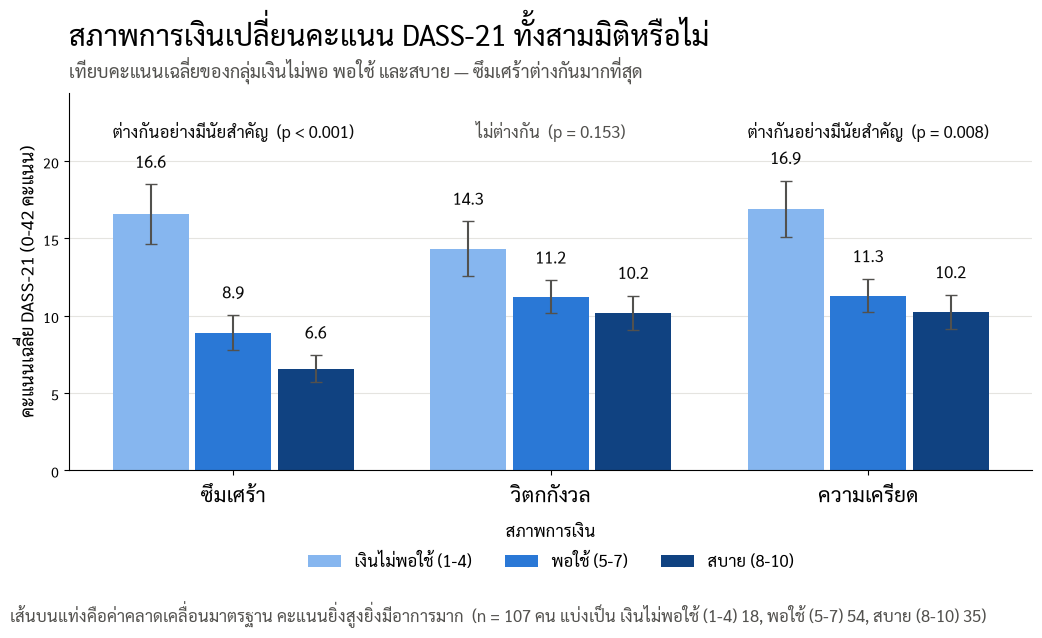

In [5]:
def plot_money(table: pd.DataFrame) -> None:
    """Three clusters, one per dimension; three bars each, one per money group."""
    plt.rcParams["font.family"] = THAI_FONT

    fig, ax = plt.subplots(figsize=(10.5, 6.4))
    width = 0.26
    x = np.arange(len(table))

    for offset, name in zip((-width, 0.0, width), GROUPS):
        means = table[f"mean_{name}"].to_numpy()
        errs = table[f"se_{name}"].to_numpy()
        ax.bar(
            x + offset,
            means,
            width=width * 0.92,  # the gap keeps neighbouring bars apart
            color=GROUP_COLOR[name],
            label=GROUP_TH[name],
            zorder=2,
        )
        ax.errorbar(
            x + offset,
            means,
            yerr=errs,
            fmt="none",
            ecolor="#52514e",
            elinewidth=1.5,
            capsize=4,
            zorder=3,
        )
        for xi, mean, err in zip(x + offset, means, errs):
            ax.annotate(  # above the whisker, not on it
                f"{mean:.1f}",
                (xi, mean + err),
                textcoords="offset points",
                xytext=(0, 12),
                ha="center",
                fontsize=12,
                color="#0b0b0b",
            )

    # p-value per dimension, written above its cluster
    top = max(table[f"mean_{name}"].max() for name in GROUPS)
    for xi, row in zip(x, table.itertuples()):
        mark = "ต่างกันอย่างมีนัยสำคัญ" if float(row.p) < ALPHA else "ไม่ต่างกัน"
        shown = "p < 0.001" if float(row.p) < 0.001 else f"p = {row.p:.3f}"
        ax.annotate(
            f"{mark}  ({shown})",
            (xi, top + 4.6),
            ha="center",
            fontsize=12,
            color="#0b0b0b" if float(row.p) < ALPHA else "#52514e",
        )

    ax.set_xticks(x)
    ax.set_xticklabels([DIMENSION_TH[d] for d in table["dimension"]], fontsize=15)
    ax.set_ylim(0, top + 7.5)
    ax.set_ylabel("คะแนนเฉลี่ย DASS-21 (0-42 คะแนน)", fontsize=13)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax.set_title(QR7_TITLES["title"], loc="left", fontsize=TITLE_SIZE, pad=34)
    ax.annotate(
        QR7_TITLES["subtitle"],
        (0.0, 1.04),
        xycoords="axes fraction",
        fontsize=13,
        color="#52514e",
    )
    # legend under the axis: the top of the plot belongs to the p-value line
    ax.legend(
        title="สภาพการเงิน",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.09),
        ncol=3,
        fontsize=12,
        title_fontsize=12,
        frameon=False,
    )

    total = int(sum(table.iloc[0][f"n_{name}"] for name in GROUPS))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.text(
        0.012,
        0.02,
        "เส้นบนแท่งคือค่าคลาดเคลื่อนมาตรฐาน คะแนนยิ่งสูงยิ่งมีอาการมาก  "
        f"(n = {total} คน แบ่งเป็น "
        + ", ".join(
            f"{GROUP_TH[name]} {int(table.iloc[0][f'n_{name}'])}" for name in GROUPS
        )
        + ")",
        fontsize=12,
        color="#52514e",
    )
    fig.savefig(QR7_FIG_PATH, dpi=200, facecolor="white")
    print(f"saved: {QR7_FIG_PATH}")
    plt.show()


plot_money(money_table)

**อ่านผล**

- **สภาพการเงินแยกคะแนนภาวะซึมเศร้าได้ชัดที่สุด** กลุ่มเงินไม่พอใช้มีคะแนนเฉลี่ย 16.6 กลุ่มสบาย 6.6
  (F(2, 104) = 10.91, p < 0.001, η² = 0.17, Cohen's d = 1.59)
- ความเครียดต่างกันเช่นกัน (F = 5.02, p = 0.008, η² = 0.09) ส่วนความวิตกกังวลไม่ต่าง (p = 0.153)
- r ของคะแนนการเงินกับภาวะซึมเศร้าคือ −0.37 เทียบกับ −0.14 ของชั่วโมงใช้โซเชียลมีเดีย
  ในกลุ่มนี้การเงินจึงเกี่ยวกับคะแนนมากกว่าเวลาหน้าจอ
- เกรดเฉลี่ยไม่สัมพันธ์กับมิติใดเลย (|r| ไม่เกิน 0.07)